In [1]:
# Data manipulation
import pandas as pd
import numpy as np

In [2]:
# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
# Ignore warnings
import warnings
warnings.filterwarnings("ignore")

In [4]:

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

In [5]:

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

In [6]:
# Evaluation
from sklearn.metrics import ( accuracy_score, confusion_matrix, classification_report, precision_score, recall_score,  f1_score,
          roc_auc_score, roc_curve )

In [7]:
# Load Dataset
df = pd.read_csv("german credit data.csv")
df.head(5)

,status_account,month_duration,credit_history,purpose,credit_amount,status_savings,years_employment,payment_to_income_ratio,status_and_sex,secondary_obligor,...,collateral,age,other_installment_plans,housing,n_credits,job,n_guarantors,telephone,is_foreign_worker,target
0,< 0 DM,6,critical account/ other credits existing (not ...,radio/television,1169,unknown/ no savings account,>= 7 years,4,male : single,none,...,none,67,none,own,2,skilled employee/ official,1,"yes, registered under the customers name",yes,good
1,0 to < 200 DM,48,existing credits paid back duly till now,radio/television,5951,< 100 DM,1 to < 4 years,2,female : divorced/separated/married,none,...,none,22,none,own,1,skilled employee/ official,1,none,yes,bad
2,no checking account,12,critical account/ other credits existing (not ...,education,2096,< 100 DM,4 to < 7 years,2,male : single,none,...,none,49,none,own,1,unskilled - resident,2,none,yes,good
3,< 0 DM,42,existing credits paid back duly till now,furniture/equipment,7882,< 100 DM,4 to < 7 years,2,male : single,guarantor,...,car,45,none,for free,1,skilled employee/ official,2,none,yes,good
4,< 0 DM,24,delay in paying off in the past,car (new),4870,< 100 DM,1 to < 4 years,3,male : single,none,...,savings agreement/life insurance,53,none,for free,2,skilled employee/ official,2,none,yes,bad


In [8]:
print("Shape of Dataset:", df.shape)

Shape of Dataset: (1000, 21)


In [9]:
df.columns

Index(['status_account', 'month_duration', 'credit_history', 'purpose',
       'credit_amount', 'status_savings', 'years_employment',
       'payment_to_income_ratio', 'status_and_sex', 'secondary_obligor',
       'residence_since', 'collateral', 'age', 'other_installment_plans',
       'housing', 'n_credits', 'job', 'n_guarantors', 'telephone',
       'is_foreign_worker', 'target'],
      dtype='object')

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 21 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   status_account           1000 non-null   object
 1   month_duration           1000 non-null   int64 
 2   credit_history           1000 non-null   object
 3   purpose                  1000 non-null   object
 4   credit_amount            1000 non-null   int64 
 5   status_savings           1000 non-null   object
 6   years_employment         1000 non-null   object
 7   payment_to_income_ratio  1000 non-null   int64 
 8   status_and_sex           1000 non-null   object
 9   secondary_obligor        1000 non-null   object
 10  residence_since          1000 non-null   int64 
 11  collateral               1000 non-null   object
 12  age                      1000 non-null   int64 
 13  other_installment_plans  1000 non-null   object
 14  housing                  1000 non-null   

In [11]:
df.describe()

,month_duration,credit_amount,payment_to_income_ratio,residence_since,age,n_credits,n_guarantors
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,20.903000,3271.258000,2.973000,2.845000,35.546000,1.407000,1.155000
std,12.058814,2822.736876,1.118715,1.103718,11.375469,0.577654,0.362086
min,4.000000,250.000000,1.000000,1.000000,19.000000,1.000000,1.000000
25%,12.000000,1365.500000,2.000000,2.000000,27.000000,1.000000,1.000000
50%,18.000000,2319.500000,3.000000,3.000000,33.000000,1.000000,1.000000
75%,24.000000,3972.250000,4.000000,4.000000,42.000000,2.000000,1.000000
max,72.000000,18424.000000,4.000000,4.000000,75.000000,4.000000,2.000000


In [12]:
df.isnull().sum()

status_account             0
month_duration             0
credit_history             0
purpose                    0
credit_amount              0
status_savings             0
years_employment           0
payment_to_income_ratio    0
status_and_sex             0
secondary_obligor          0
residence_since            0
collateral                 0
age                        0
other_installment_plans    0
housing                    0
n_credits                  0
job                        0
n_guarantors               0
telephone                  0
is_foreign_worker          0
target                     0
dtype: int64

In [13]:
print("Duplicate Rows:", df.duplicated().sum())

Duplicate Rows: 0


In [14]:
df['target'].value_counts()

target
good    700
bad     300
Name: count, dtype: int64

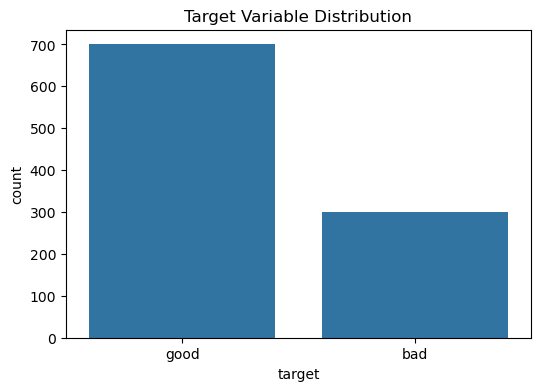

In [15]:
plt.figure(figsize=(6,4))

sns.countplot(x='target', data=df)

plt.title("Target Variable Distribution")

plt.show()

In [16]:
missing_values = df.isnull().sum()

print(missing_values)

status_account             0
month_duration             0
credit_history             0
purpose                    0
credit_amount              0
status_savings             0
years_employment           0
payment_to_income_ratio    0
status_and_sex             0
secondary_obligor          0
residence_since            0
collateral                 0
age                        0
other_installment_plans    0
housing                    0
n_credits                  0
job                        0
n_guarantors               0
telephone                  0
is_foreign_worker          0
target                     0
dtype: int64


In [17]:
duplicates = df.duplicated().sum()

print("Duplicate Rows:", duplicates)

Duplicate Rows: 0


In [18]:
df.dtypes

status_account             object
month_duration              int64
credit_history             object
purpose                    object
credit_amount               int64
status_savings             object
years_employment           object
payment_to_income_ratio     int64
status_and_sex             object
secondary_obligor          object
residence_since             int64
collateral                 object
age                         int64
other_installment_plans    object
housing                    object
n_credits                   int64
job                        object
n_guarantors                int64
telephone                  object
is_foreign_worker          object
target                     object
dtype: object

In [19]:
numerical_columns = df.select_dtypes(include=['int64','float64']).columns

categorical_columns = df.select_dtypes(include=['object']).columns

print("Numerical Columns")
print(numerical_columns)

print("\nCategorical Columns")
print(categorical_columns)

Numerical Columns
Index(['month_duration', 'credit_amount', 'payment_to_income_ratio',
       'residence_since', 'age', 'n_credits', 'n_guarantors'],
      dtype='object')

Categorical Columns
Index(['status_account', 'credit_history', 'purpose', 'status_savings',
       'years_employment', 'status_and_sex', 'secondary_obligor', 'collateral',
       'other_installment_plans', 'housing', 'job', 'telephone',
       'is_foreign_worker', 'target'],
      dtype='object')


In [20]:
for column in categorical_columns:
    print("="*60)
    print(column)
    print(df[column].unique())

status_account
['< 0 DM' '0 to < 200 DM' 'no checking account' '>= 200 DM']
credit_history
['critical account/ other credits existing (not at this bank)'
 'existing credits paid back duly till now'
 'delay in paying off in the past'
 'no credits taken/ all credits paid back duly'
 'all credits at this bank paid back duly']
purpose
['radio/television' 'education' 'furniture/equipment' 'car (new)'
 'car (used)' 'business' 'domestic appliances' 'repairs' 'others'
 'retraining']
status_savings
['unknown/ no savings account' '< 100 DM' '500 to < 1000 DM' '>= 1000 DM'
 '100 to < 500 DM']
years_employment
['>= 7 years' '1 to < 4 years' '4 to < 7 years' 'unemployed' '< 1 year']
status_and_sex
['male : single' 'female : divorced/separated/married'
 'male : divorced/separated' 'male : married/widowed']
secondary_obligor
['none' 'guarantor' 'co-applicant']
collateral
['none' 'car' 'savings agreement/life insurance' 'real estate']
other_installment_plans
['none' 'bank' 'stores']
housing
['own' 'fo

In [21]:
for column in categorical_columns:
    print(f"{column} : {df[column].nunique()} unique values")

status_account : 4 unique values
credit_history : 5 unique values
purpose : 10 unique values
status_savings : 5 unique values
years_employment : 5 unique values
status_and_sex : 4 unique values
secondary_obligor : 3 unique values
collateral : 4 unique values
other_installment_plans : 3 unique values
housing : 3 unique values
job : 4 unique values
telephone : 2 unique values
is_foreign_worker : 2 unique values
target : 2 unique values


In [22]:
df['target'].value_counts()

target
good    700
bad     300
Name: count, dtype: int64

In [23]:
df['target'].value_counts(normalize=True)*100

target
good    70.0
bad     30.0
Name: proportion, dtype: float64

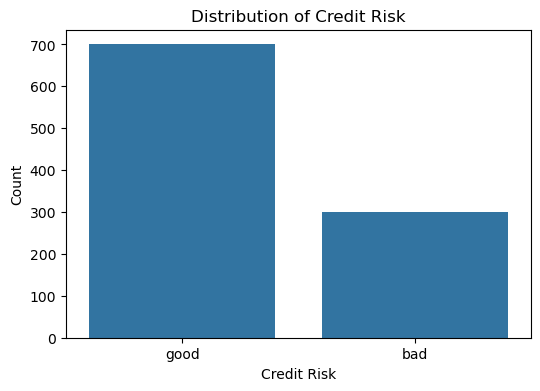

In [24]:
plt.figure(figsize=(6,4))

sns.countplot(x='target', data=df)

plt.title("Distribution of Credit Risk")
plt.xlabel("Credit Risk")
plt.ylabel("Count")

plt.show()

In [25]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
month_duration,1000.0,20.903,12.058814,4.0,12.0,18.0,24.00,72.0
credit_amount,1000.0,3271.258,2822.736876,250.0,1365.5,2319.5,3972.25,18424.0
payment_to_income_ratio,1000.0,2.973,1.118715,1.0,2.0,3.0,4.00,4.0
residence_since,1000.0,2.845,1.103718,1.0,2.0,3.0,4.00,4.0
age,1000.0,35.546,11.375469,19.0,27.0,33.0,42.00,75.0
n_credits,1000.0,1.407,0.577654,1.0,1.0,1.0,2.00,4.0
n_guarantors,1000.0,1.155,0.362086,1.0,1.0,1.0,1.00,2.0


In [26]:
for column in categorical_columns:

    print("\n" + "="*50)
    print(column)

    print(df[column].value_counts())


status_account
status_account
no checking account    394
< 0 DM                 274
0 to < 200 DM          269
>= 200 DM               63
Name: count, dtype: int64

credit_history
credit_history
existing credits paid back duly till now                       530
critical account/ other credits existing (not at this bank)    293
delay in paying off in the past                                 88
all credits at this bank paid back duly                         49
no credits taken/ all credits paid back duly                    40
Name: count, dtype: int64

purpose
purpose
radio/television       280
car (new)              234
furniture/equipment    181
car (used)             103
business                97
education               50
repairs                 22
domestic appliances     12
others                  12
retraining               9
Name: count, dtype: int64

status_savings
status_savings
< 100 DM                       603
unknown/ no savings account    183
100 to < 500 DM              

In [27]:
plt.style.use("ggplot")
sns.set(font_scale=1.1)

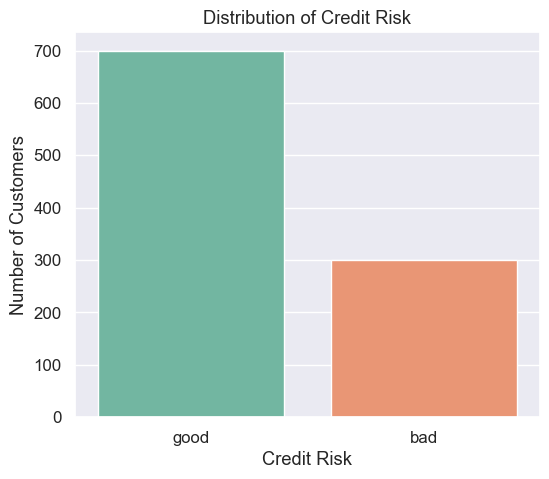

In [28]:
plt.figure(figsize=(6,5))

sns.countplot(x='target', data=df, palette='Set2')

plt.title("Distribution of Credit Risk")
plt.xlabel("Credit Risk")
plt.ylabel("Number of Customers")

plt.show()

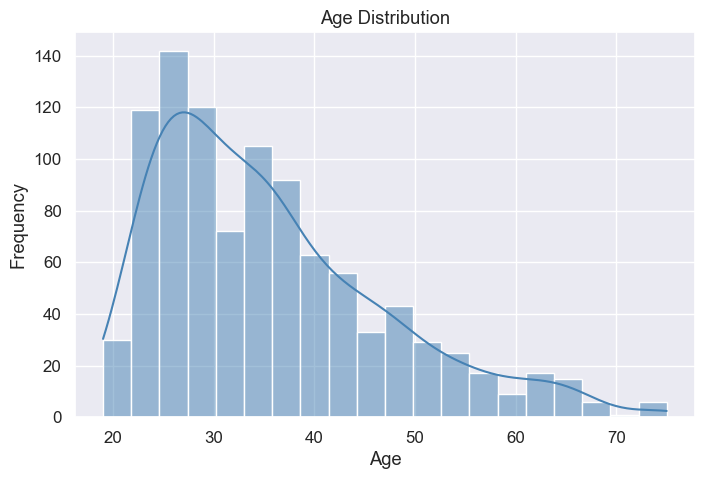

In [29]:
plt.figure(figsize=(8,5))

sns.histplot(df['age'], bins=20, kde=True, color='steelblue')

plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Frequency")

plt.show()

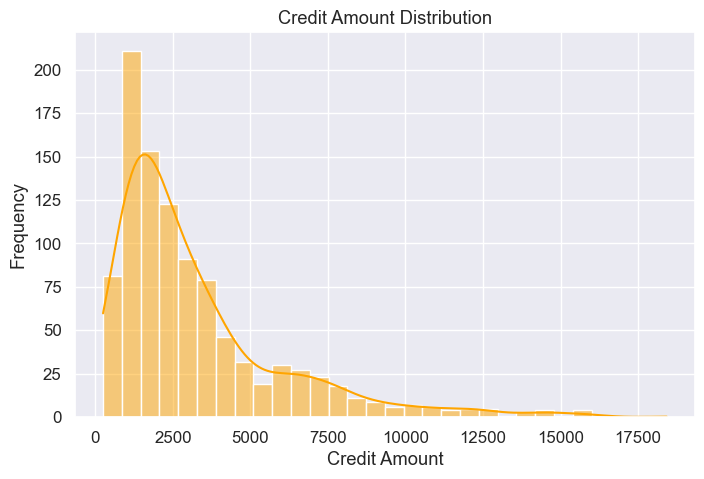

In [30]:
plt.figure(figsize=(8,5))

sns.histplot(df['credit_amount'], bins=30, kde=True, color='orange')

plt.title("Credit Amount Distribution")
plt.xlabel("Credit Amount")
plt.ylabel("Frequency")

plt.show()

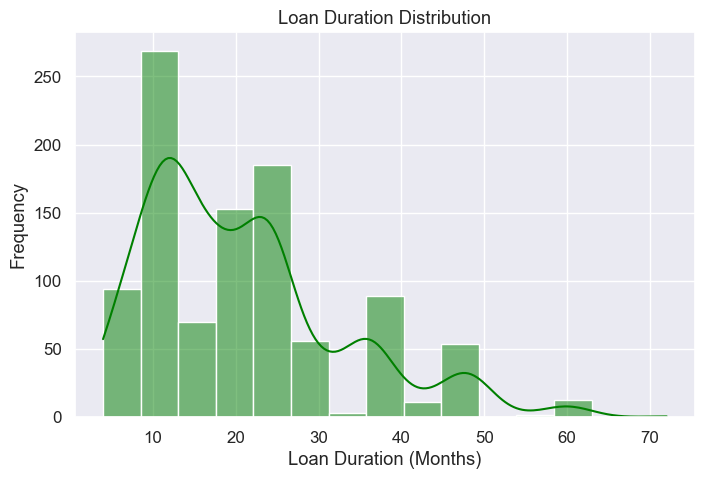

In [31]:
plt.figure(figsize=(8,5))

sns.histplot(df['month_duration'], bins=15, kde=True, color='green')

plt.title("Loan Duration Distribution")
plt.xlabel("Loan Duration (Months)")
plt.ylabel("Frequency")

plt.show()

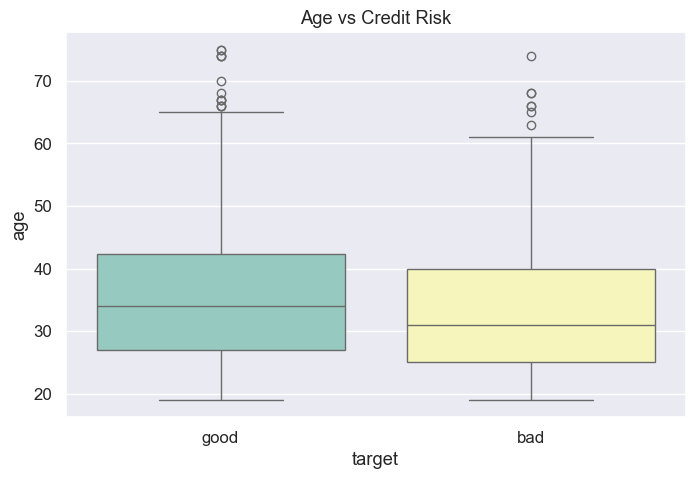

In [32]:
plt.figure(figsize=(8,5))

sns.boxplot(x='target',
            y='age',
            data=df,
            palette='Set3')

plt.title("Age vs Credit Risk")

plt.show()

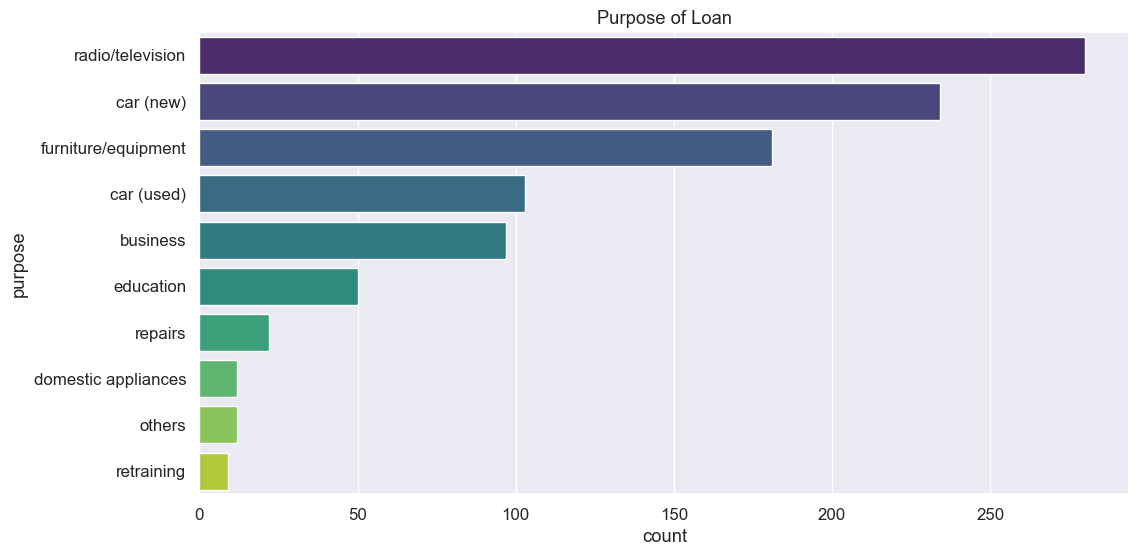

In [33]:
plt.figure(figsize=(12,6))

sns.countplot(y='purpose',
              data=df,
              order=df['purpose'].value_counts().index,
              palette='viridis')

plt.title("Purpose of Loan")

plt.show()

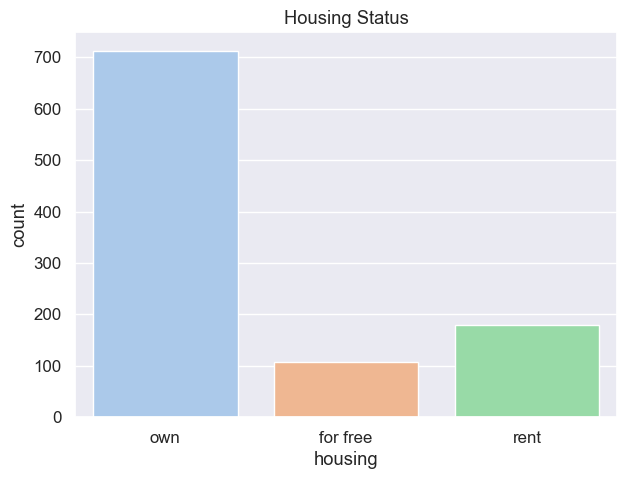

In [34]:
plt.figure(figsize=(7,5))

sns.countplot(x='housing',
              data=df,
              palette='pastel')

plt.title("Housing Status")

plt.show()

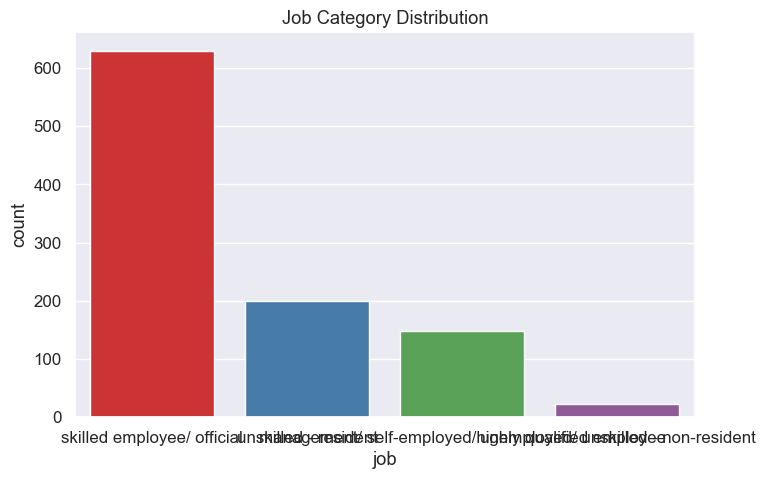

In [35]:
plt.figure(figsize=(8,5))

sns.countplot(x='job',
              data=df,
              palette='Set1')

plt.title("Job Category Distribution")

plt.show()

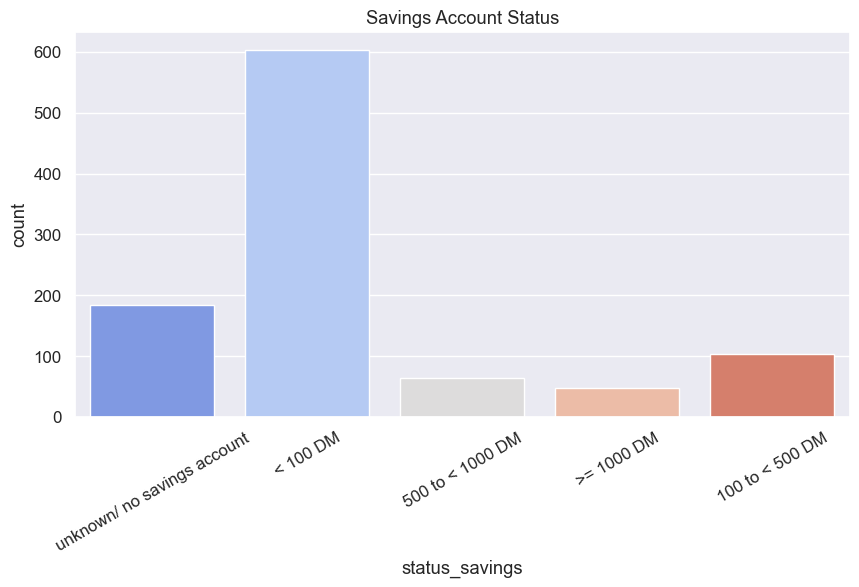

In [36]:
plt.figure(figsize=(10,5))

sns.countplot(x='status_savings',
              data=df,
              palette='coolwarm')

plt.title("Savings Account Status")

plt.xticks(rotation=30)

plt.show()

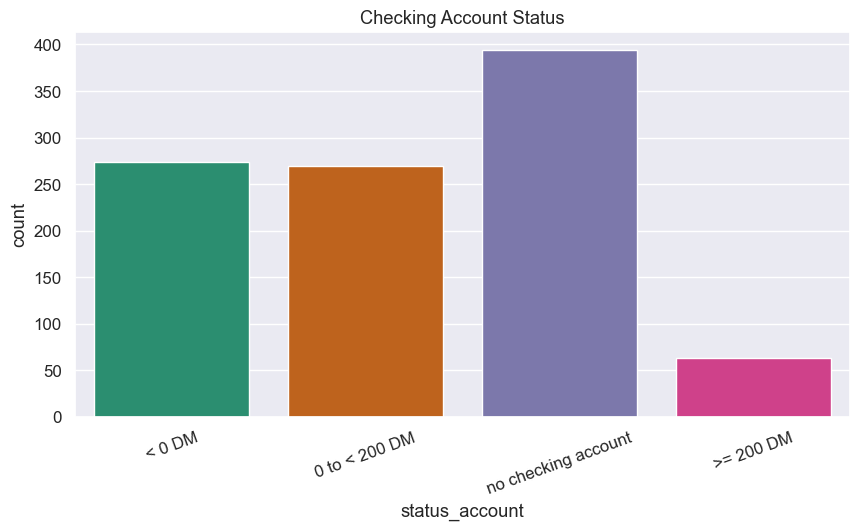

In [37]:
plt.figure(figsize=(10,5))

sns.countplot(x='status_account',
              data=df,
              palette='Dark2')

plt.title("Checking Account Status")

plt.xticks(rotation=20)

plt.show()

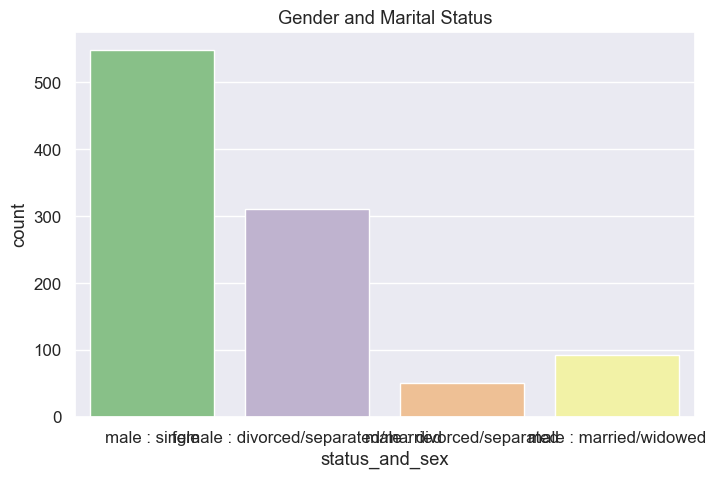

In [38]:
plt.figure(figsize=(8,5))

sns.countplot(x='status_and_sex',
              data=df,
              palette='Accent')

plt.title("Gender and Marital Status")

plt.show()

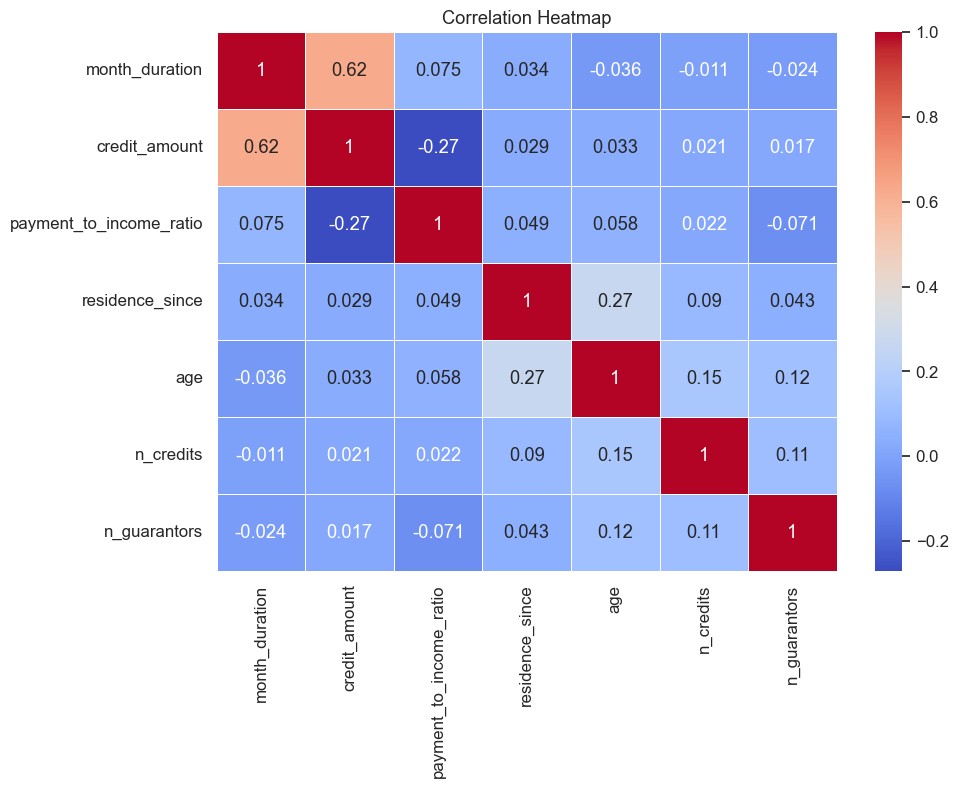

In [39]:
plt.figure(figsize=(10,7))

sns.heatmap(df.select_dtypes(include=['int64','float64']).corr(),
            annot=True,
            cmap='coolwarm',
            linewidths=0.5)

plt.title("Correlation Heatmap")

plt.show()

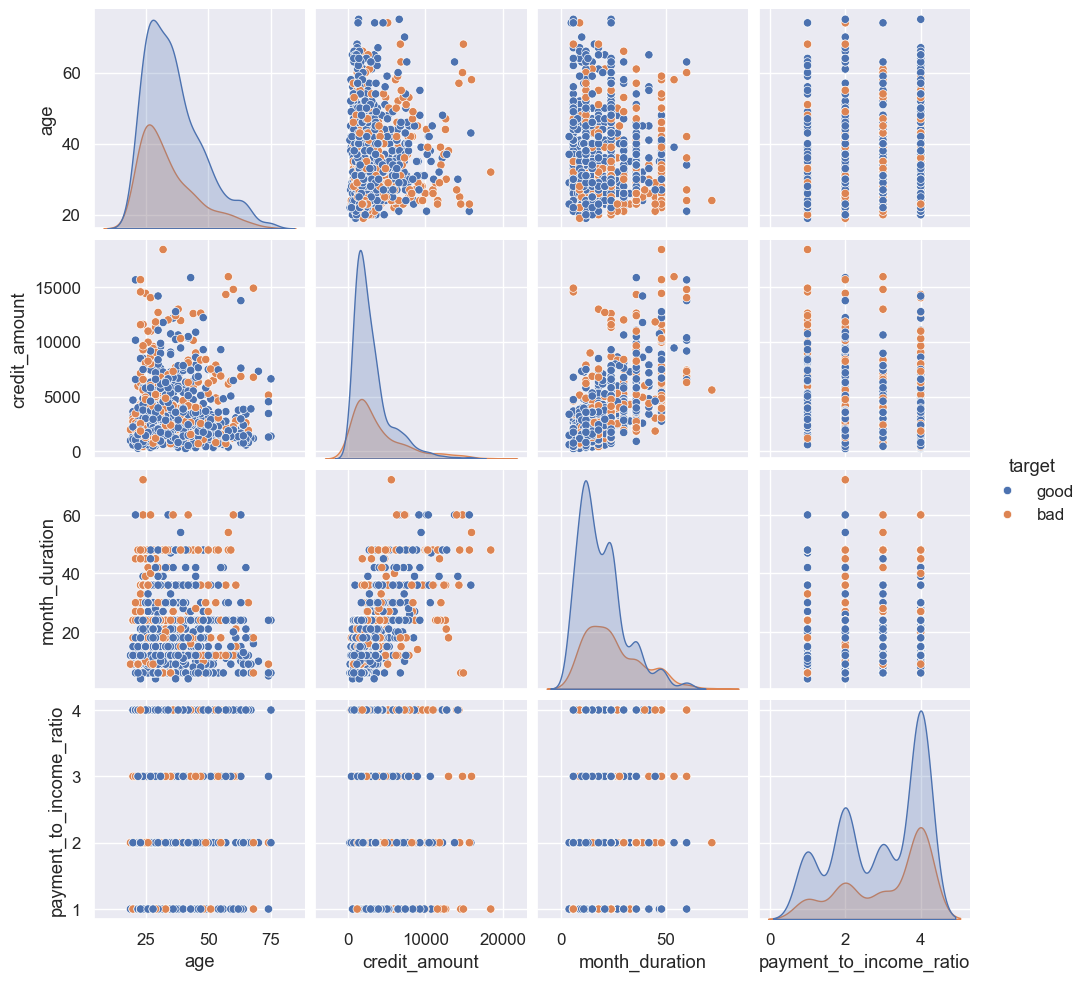

In [40]:
sns.pairplot(
    df[['age',
        'credit_amount',
        'month_duration',
        'payment_to_income_ratio',
        'target']],
    hue='target'
)

plt.show()

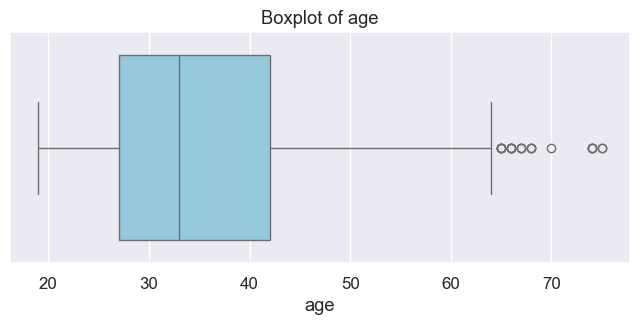

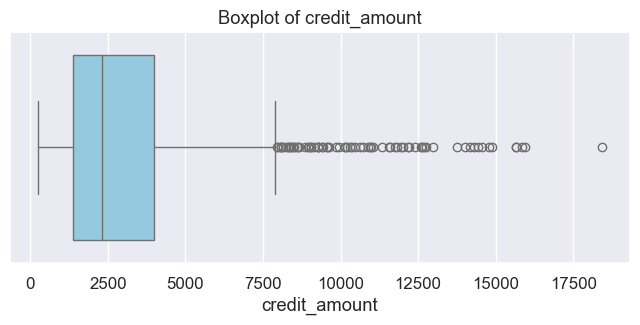

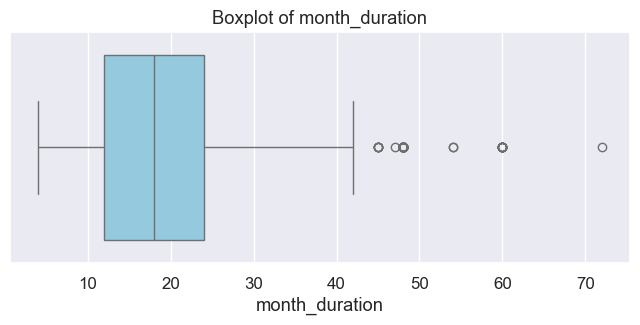

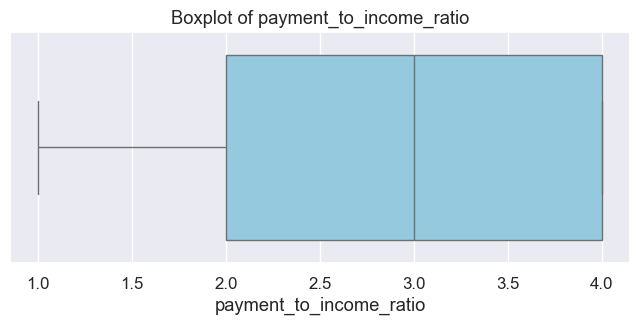

In [41]:
numerical_columns = ['age',
                     'credit_amount',
                     'month_duration',
                     'payment_to_income_ratio']

for col in numerical_columns:

    plt.figure(figsize=(8,3))

    sns.boxplot(x=df[col], color='skyblue')

    plt.title(f"Boxplot of {col}")

    plt.show()

In [42]:
# Create a Copy of Dataset

data = df.copy()

data.head()

,status_account,month_duration,credit_history,purpose,credit_amount,status_savings,years_employment,payment_to_income_ratio,status_and_sex,secondary_obligor,...,collateral,age,other_installment_plans,housing,n_credits,job,n_guarantors,telephone,is_foreign_worker,target
0,< 0 DM,6,critical account/ other credits existing (not ...,radio/television,1169,unknown/ no savings account,>= 7 years,4,male : single,none,...,none,67,none,own,2,skilled employee/ official,1,"yes, registered under the customers name",yes,good
1,0 to < 200 DM,48,existing credits paid back duly till now,radio/television,5951,< 100 DM,1 to < 4 years,2,female : divorced/separated/married,none,...,none,22,none,own,1,skilled employee/ official,1,none,yes,bad
2,no checking account,12,critical account/ other credits existing (not ...,education,2096,< 100 DM,4 to < 7 years,2,male : single,none,...,none,49,none,own,1,unskilled - resident,2,none,yes,good
3,< 0 DM,42,existing credits paid back duly till now,furniture/equipment,7882,< 100 DM,4 to < 7 years,2,male : single,guarantor,...,car,45,none,for free,1,skilled employee/ official,2,none,yes,good
4,< 0 DM,24,delay in paying off in the past,car (new),4870,< 100 DM,1 to < 4 years,3,male : single,none,...,savings agreement/life insurance,53,none,for free,2,skilled employee/ official,2,none,yes,bad


In [43]:
# Age Groups

data['age_group'] = pd.cut(
    data['age'],
    bins=[18,25,35,50,100],
    labels=['18-25','26-35','36-50','50+']
)

data[['age','age_group']].head()



,age,age_group
0,67,50+
1,22,18-25
2,49,36-50
3,45,36-50
4,53,50+


In [44]:
data['loan_category'] = pd.qcut(
    data['credit_amount'],
    q=4,
    labels=[
        'Low',
        'Medium',
        'High',
        'Very High'
    ]
)

data[['credit_amount','loan_category']].head()

,credit_amount,loan_category
0,1169,Low
1,5951,Very High
2,2096,Medium
3,7882,Very High
4,4870,Very High


In [45]:
data['long_term_loan'] = np.where(
    data['month_duration'] > 24,
    1,
    0
)

data[['month_duration','long_term_loan']].head()

,month_duration,long_term_loan
0,6,0
1,48,1
2,12,0
3,42,1
4,24,0


In [46]:
data.head()

,status_account,month_duration,credit_history,purpose,credit_amount,status_savings,years_employment,payment_to_income_ratio,status_and_sex,secondary_obligor,...,housing,n_credits,job,n_guarantors,telephone,is_foreign_worker,target,age_group,loan_category,long_term_loan
0,< 0 DM,6,critical account/ other credits existing (not ...,radio/television,1169,unknown/ no savings account,>= 7 years,4,male : single,none,...,own,2,skilled employee/ official,1,"yes, registered under the customers name",yes,good,50+,Low,0
1,0 to < 200 DM,48,existing credits paid back duly till now,radio/television,5951,< 100 DM,1 to < 4 years,2,female : divorced/separated/married,none,...,own,1,skilled employee/ official,1,none,yes,bad,18-25,Very High,1
2,no checking account,12,critical account/ other credits existing (not ...,education,2096,< 100 DM,4 to < 7 years,2,male : single,none,...,own,1,unskilled - resident,2,none,yes,good,36-50,Medium,0
3,< 0 DM,42,existing credits paid back duly till now,furniture/equipment,7882,< 100 DM,4 to < 7 years,2,male : single,guarantor,...,for free,1,skilled employee/ official,2,none,yes,good,36-50,Very High,1
4,< 0 DM,24,delay in paying off in the past,car (new),4870,< 100 DM,1 to < 4 years,3,male : single,none,...,for free,2,skilled employee/ official,2,none,yes,bad,50+,Very High,0


In [47]:
data['target'] = data['target'].map({
    'good':1,
    'bad':0
})

data['target'].value_counts()

target
1    700
0    300
Name: count, dtype: int64

In [48]:
X = data.drop('target', axis=1)

y = data['target']

In [49]:
categorical_columns = X.select_dtypes(include='object').columns

numerical_columns = X.select_dtypes(
    include=['int64','float64']
).columns

print("Categorical Columns")
print(categorical_columns)

print()

print("Numerical Columns")
print(numerical_columns)

Categorical Columns
Index(['status_account', 'credit_history', 'purpose', 'status_savings',
       'years_employment', 'status_and_sex', 'secondary_obligor', 'collateral',
       'other_installment_plans', 'housing', 'job', 'telephone',
       'is_foreign_worker'],
      dtype='object')

Numerical Columns
Index(['month_duration', 'credit_amount', 'payment_to_income_ratio',
       'residence_since', 'age', 'n_credits', 'n_guarantors',
       'long_term_loan'],
      dtype='object')


In [50]:
categorical_columns = X.select_dtypes(
    include=['object','category']
).columns

categorical_columns

Index(['status_account', 'credit_history', 'purpose', 'status_savings',
       'years_employment', 'status_and_sex', 'secondary_obligor', 'collateral',
       'other_installment_plans', 'housing', 'job', 'telephone',
       'is_foreign_worker', 'age_group', 'loan_category'],
      dtype='object')

In [51]:
X = pd.get_dummies(
    X,
    drop_first=True
)

X.head()

,month_duration,credit_amount,payment_to_income_ratio,residence_since,age,n_credits,n_guarantors,long_term_loan,status_account_< 0 DM,status_account_>= 200 DM,...,job_unemployed/ unskilled - non-resident,job_unskilled - resident,"telephone_yes, registered under the customers name",is_foreign_worker_yes,age_group_26-35,age_group_36-50,age_group_50+,loan_category_Medium,loan_category_High,loan_category_Very High
0,6,1169,4,4,67,2,1,0,True,False,...,False,False,True,True,False,False,True,False,False,False
1,48,5951,2,2,22,1,1,1,False,False,...,False,False,False,True,False,False,False,False,False,True
2,12,2096,2,3,49,1,2,0,False,False,...,False,True,False,True,False,True,False,True,False,False
3,42,7882,2,4,45,1,2,1,True,False,...,False,False,False,True,False,True,False,False,False,True
4,24,4870,3,4,53,2,2,0,True,False,...,False,False,False,True,False,False,True,False,False,True


In [52]:
print("Shape Before Encoding:", df.shape)

print("Shape After Encoding:", X.shape)

Shape Before Encoding: (1000, 21)
Shape After Encoding: (1000, 55)


In [53]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training Shape:", X_train.shape)

print("Testing Shape:", X_test.shape)

Training Shape: (800, 55)
Testing Shape: (200, 55)


In [55]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

In [56]:
print("X_train :", X_train.shape)
print("X_test  :", X_test.shape)

print("y_train :", y_train.shape)
print("y_test  :", y_test.shape)

X_train : (800, 55)
X_test  : (200, 55)
y_train : (800,)
y_test  : (200,)


In [57]:
from sklearn.metrics import ( accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report, roc_auc_score,
       RocCurveDisplay)

In [61]:
def evaluate_model(model, X_train, X_test, y_train, y_test):

    # Train the model
    model.fit(X_train, y_train)

    # Predictions
    y_pred = model.predict(X_test)

    # Probabilities (for ROC-AUC)
    if hasattr(model, "predict_proba"):
        y_prob = model.predict_proba(X_test)[:,1]
    else:
        y_prob = None

    # Print Metrics
    print("="*60)
    print("Model:", model.__class__.__name__)
    print("="*60)

    print("Accuracy :", round(accuracy_score(y_test, y_pred),4))
    print("Precision:", round(precision_score(y_test, y_pred),4))
    print("Recall   :", round(recall_score(y_test, y_pred),4))
    print("F1 Score :", round(f1_score(y_test, y_pred),4))

    if y_prob is not None:
        print("ROC-AUC  :", round(roc_auc_score(y_test, y_prob),4))

    print("\nClassification Report\n")
    print(classification_report(y_test, y_pred))

    # Confusion Matrix
    plt.figure(figsize=(5,4))

    sns.heatmap(
        confusion_matrix(y_test, y_pred),
        annot=True,
        fmt='d',
        cmap='Blues'
    )

    plt.title(model.__class__.__name__)
    plt.xlabel("Predicted")
    plt.ylabel("Actual")

    plt.show()

    # ROC Curve
    if y_prob is not None:
        RocCurveDisplay.from_predictions(y_test, y_prob)
        plt.title(f"ROC Curve - {model.__class__.__name__}")
        plt.show()

Model: LogisticRegression
Accuracy : 0.695
Precision: 0.7687
Recall   : 0.8071
F1 Score : 0.7875
ROC-AUC  : 0.7462

Classification Report

              precision    recall  f1-score   support

           0       0.49      0.43      0.46        60
           1       0.77      0.81      0.79       140

    accuracy                           0.69       200
   macro avg       0.63      0.62      0.62       200
weighted avg       0.69      0.69      0.69       200



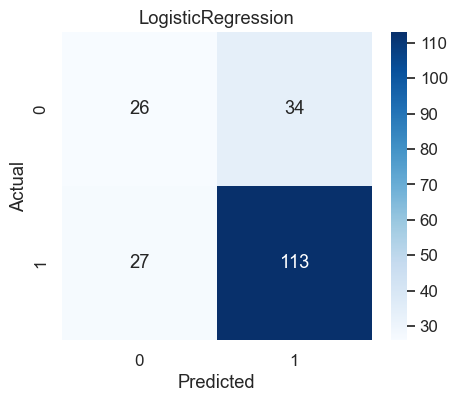

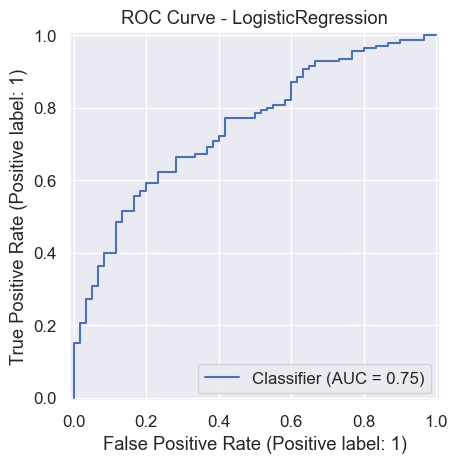

In [62]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(random_state=42)

evaluate_model(
    lr,
    X_train_scaled,
    X_test_scaled,
    y_train,
    y_test
)

Model: DecisionTreeClassifier
Accuracy : 0.68
Precision: 0.7879
Recall   : 0.7429
F1 Score : 0.7647
ROC-AUC  : 0.6381

Classification Report

              precision    recall  f1-score   support

           0       0.47      0.53      0.50        60
           1       0.79      0.74      0.76       140

    accuracy                           0.68       200
   macro avg       0.63      0.64      0.63       200
weighted avg       0.69      0.68      0.69       200



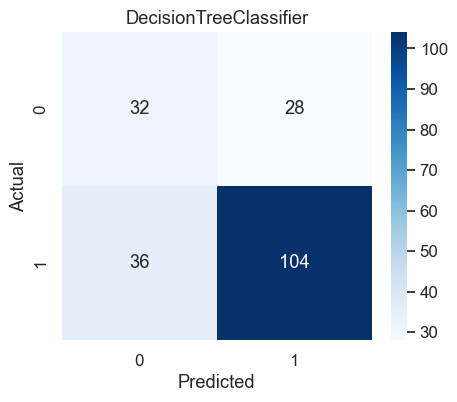

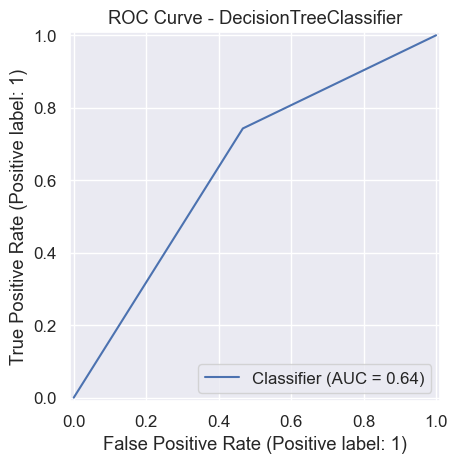

In [63]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(
    random_state=42
)

evaluate_model(
    dt,
    X_train,
    X_test,
    y_train,
    y_test
)

Model: RandomForestClassifier
Accuracy : 0.755
Precision: 0.7758
Recall   : 0.9143
F1 Score : 0.8393
ROC-AUC  : 0.7986

Classification Report

              precision    recall  f1-score   support

           0       0.66      0.38      0.48        60
           1       0.78      0.91      0.84       140

    accuracy                           0.76       200
   macro avg       0.72      0.65      0.66       200
weighted avg       0.74      0.76      0.73       200



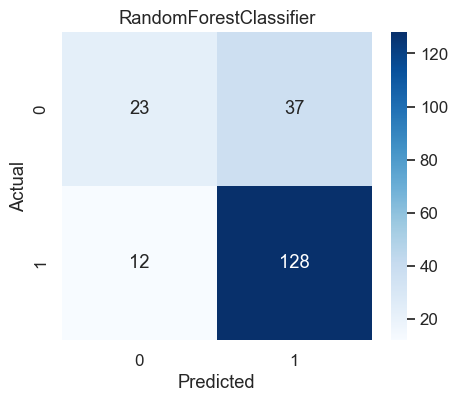

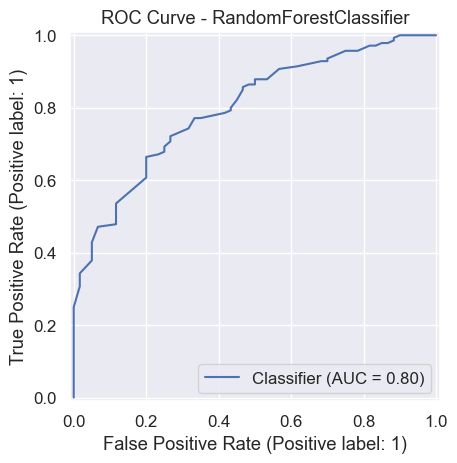

In [64]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    random_state=42
)

evaluate_model(
    rf,
    X_train,
    X_test,
    y_train,
    y_test
)

In [65]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

results = []

models = {

    "Logistic Regression":
        LogisticRegression(random_state=42),

    "Decision Tree":
        DecisionTreeClassifier(random_state=42),

    "Random Forest":
        RandomForestClassifier(random_state=42)

}

for name, model in models.items():

    if name == "Logistic Regression":

        model.fit(X_train_scaled, y_train)

        pred = model.predict(X_test_scaled)

        prob = model.predict_proba(X_test_scaled)[:,1]

    else:

        model.fit(X_train, y_train)

        pred = model.predict(X_test)

        prob = model.predict_proba(X_test)[:,1]

    results.append({

        "Model": name,

        "Accuracy": accuracy_score(y_test, pred),

        "Precision": precision_score(y_test, pred),

        "Recall": recall_score(y_test, pred),

        "F1 Score": f1_score(y_test, pred),

        "ROC-AUC": roc_auc_score(y_test, prob)

    })

results_df = pd.DataFrame(results)

results_df.sort_values(
    by="ROC-AUC",
    ascending=False
)

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
2,Random Forest,0.755,0.775758,0.914286,0.839344,0.798631
0,Logistic Regression,0.695,0.768707,0.807143,0.787456,0.746190
1,Decision Tree,0.680,0.787879,0.742857,0.764706,0.638095


In [66]:
RandomForestClassifier(random_state=42)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [67]:
from sklearn.model_selection import GridSearchCV


In [68]:
# Hyperparameter Grid
param_grid = {

    'n_estimators': [100, 200, 300],

    'max_depth': [5, 10, 15, None],

    'min_samples_split': [2, 5, 10],

    'min_samples_leaf': [1, 2, 4],

    'max_features': ['sqrt', 'log2']

}

In [69]:
rf = RandomForestClassifier(
    random_state=42
)

In [82]:
grid_search = GridSearchCV(

    estimator=rf,

    param_grid=param_grid,

    cv=5,

    scoring='f1',

    n_jobs=-1,

    verbose=2

)

grid_search.fit(X_train, y_train)

Fitting 5 folds for each of 216 candidates, totalling 1080 fits


,estimator,RandomForestC...ndom_state=42)
,param_grid,"{'max_depth': [5, 10, ...], 'max_features': ['sqrt', 'log2'], 'min_samples_leaf': [1, 2, ...], 'min_samples_split': [2, 5, ...], ...}"
,scoring,'f1'
,n_jobs,-1
,refit,True
,cv,5
,verbose,2
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,n_estimators,200


In [71]:
print("Best Parameters:")

print(grid_search.best_params_)

Best Parameters:
{'max_depth': 15, 'max_features': 'sqrt', 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 200}


In [72]:
best_rf = grid_search.best_estimator_

Model: RandomForestClassifier
Accuracy : 0.765
Precision: 0.7818
Recall   : 0.9214
F1 Score : 0.8459
ROC-AUC  : 0.7768

Classification Report

              precision    recall  f1-score   support

           0       0.69      0.40      0.51        60
           1       0.78      0.92      0.85       140

    accuracy                           0.77       200
   macro avg       0.73      0.66      0.68       200
weighted avg       0.75      0.77      0.74       200



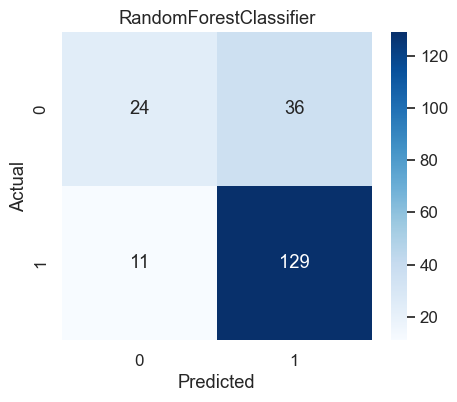

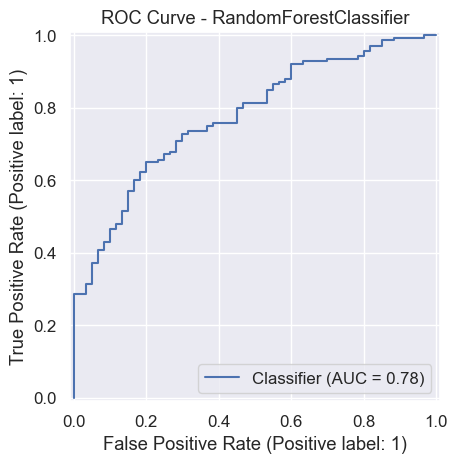

In [74]:
evaluate_model( best_rf,  X_train,  X_test,  y_train,  y_test)

In [75]:
before = RandomForestClassifier(random_state=42)

before.fit(X_train, y_train)

before_pred = before.predict(X_test)

after_pred = best_rf.predict(X_test)

comparison = pd.DataFrame({

    "Model":[

        "Random Forest",

        "Tuned Random Forest"

    ],

    "Accuracy":[

        accuracy_score(y_test,before_pred),

        accuracy_score(y_test,after_pred)

    ],

    "Precision":[

        precision_score(y_test,before_pred),

        precision_score(y_test,after_pred)

    ],

    "Recall":[

        recall_score(y_test,before_pred),

        recall_score(y_test,after_pred)

    ],

    "F1 Score":[

        f1_score(y_test,before_pred),

        f1_score(y_test,after_pred)

    ]

})

comparison

,Model,Accuracy,Precision,Recall,F1 Score
0,Random Forest,0.755,0.775758,0.914286,0.839344
1,Tuned Random Forest,0.765,0.781818,0.921429,0.845902


In [76]:
feature_importance = pd.DataFrame({

    "Feature": X.columns,

    "Importance": best_rf.feature_importances_

})

feature_importance = feature_importance.sort_values(

    by="Importance",

    ascending=False

)

feature_importance.head(15)

,Feature,Importance
1,credit_amount,0.106603
0,month_duration,0.087811
4,age,0.075313
10,status_account_no checking account,0.070707
8,status_account_< 0 DM,0.048510
2,payment_to_income_ratio,0.033510
3,residence_since,0.030620
11,credit_history_critical account/ other credits...,0.026367
25,status_savings_< 100 DM,0.024905
15,purpose_car (new),0.024096


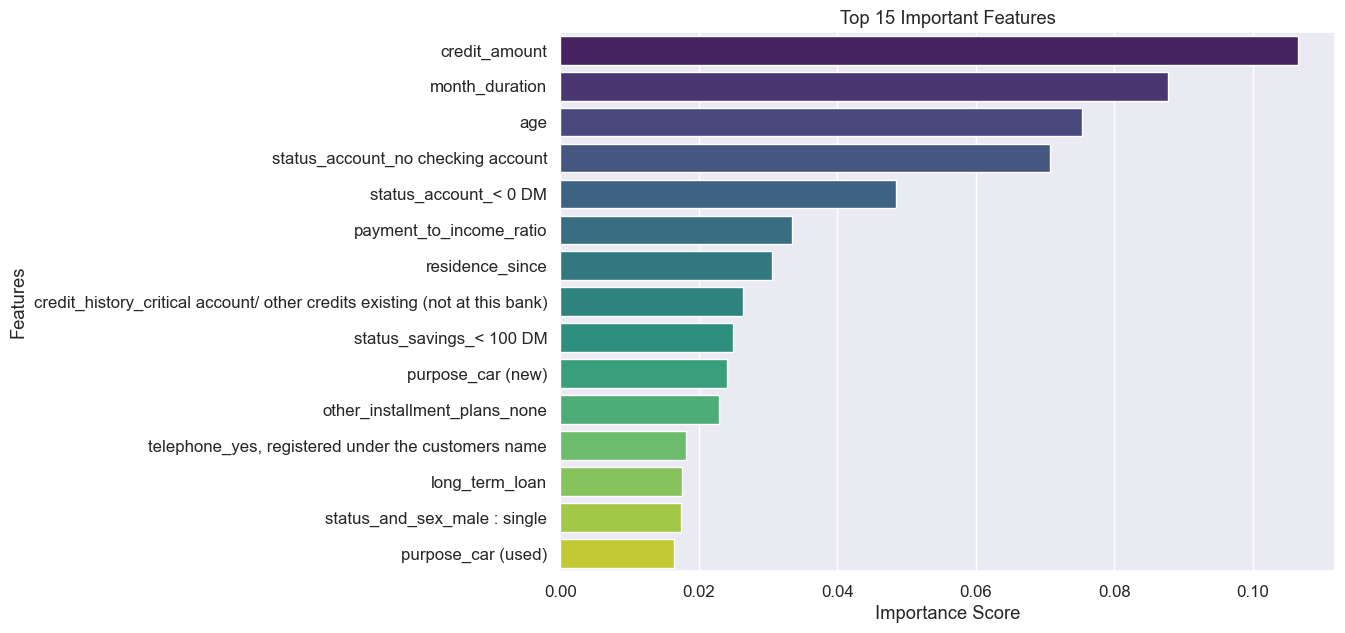

In [77]:
plt.figure(figsize=(10,7))

sns.barplot(

    data=feature_importance.head(15),

    x="Importance",

    y="Feature",

    palette="viridis"

)

plt.title("Top 15 Important Features")

plt.xlabel("Importance Score")

plt.ylabel("Features")

plt.show()

In [78]:
import joblib

joblib.dump(best_rf, "credit_scoring_model.pkl")

print("Model Saved Successfully!")

Model Saved Successfully!


In [79]:
joblib.dump(scaler, "scaler.pkl")

['scaler.pkl']

In [80]:
loaded_model = joblib.load("credit_scoring_model.pkl")

In [81]:
# Select one customer from the test data
sample_customer = X_test.iloc[[0]]

prediction = loaded_model.predict(sample_customer)

probability = loaded_model.predict_proba(sample_customer)

print("Prediction:", prediction)
print("Probability:", probability)

Prediction: [1]
Probability: [[0.13899767 0.86100233]]


In [83]:
# check for overfitting 
train_accuracy = best_rf.score(X_train, y_train)

test_accuracy = best_rf.score(X_test, y_test)

print("Training Accuracy :", train_accuracy)

print("Testing Accuracy :", test_accuracy)

Training Accuracy : 0.9575
Testing Accuracy : 0.765
